<a href="https://colab.research.google.com/github/jane-kirina/python_for_ds_and_ml_tasks/blob/main/module_2/topic_1/HW_2_1_5_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Імпорт бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [ ]:
# Імпорт даних
from google.colab import drive
drive.mount('/content/drive')
medical_df = pd.read_csv('drive/MyDrive/Colab Notebooks/_DLA_/module_2/data/medical-charges.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

# Завдання 1

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [ ]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [ ]:
age = non_smoker_df['age'].values
charges = non_smoker_df['charges'].values
age_line = np.linspace(age.min(), age.max(), 100)

## Метод МНК (тільки numpy, без scikit learn)

In [ ]:
def ols(X, y, fit_intercept=True):
    X = np.array(X)
    y = np.array(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    if fit_intercept:
        X = np.hstack((np.ones((X.shape[0], 1)), X))

    return np.linalg.solve(X.T @ X, X.T @ y)

In [ ]:
X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

theta = ols(X, y, fit_intercept=True)  # [b, w]
b, w = theta[0], theta[1]

charges_ols = b + w * age_line

print(f'Weight= {w:.4f}')
print(f'Bias = {b:.2f}')

Weight= 267.2489
Bias = -2091.42


## Full-Batch градієнтного спуску з numpy

In [ ]:
class SimpleLinearRegression:
    def __init__(self, learning_rate=0.01, epochs=2000):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

        self.weight = None
        self.bias = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1)

        n_samples, n_features = X.shape

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.weight = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.epochs):
            y_predicted = np.dot(X, self.weight) + self.bias
            err = y_predicted - y

            # MSE loss
            loss = np.mean(err ** 2)
            self.loss_history.append(loss)

            bias_derivative = (1 / n_samples) * np.sum(y_predicted - y)
            weight_derivative = (1 / n_samples) * np.dot(X.T, (y_predicted - y))

            self.bias -= self.learning_rate * bias_derivative
            self.weight -= self.learning_rate * weight_derivative


    def predict(self, X):
        return np.dot(np.array(X), self.weight) + self.bias

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [ ]:
def test_learning_rate(X, y, learning_rate_list, epochs):
  results = []
  histories = {}
  models = {}

  for learning_rate in learning_rate_list:
    model = SimpleLinearRegression(learning_rate=learning_rate, epochs=epochs)
    model.fit(X, y)
    y_pred = model.predict(X)

    score = rmse(y, y_pred)
    results.append((score, learning_rate))
    histories[learning_rate] = model.loss_history
    models[learning_rate] = model

  return results, histories, models

In [ ]:
def draw_learning_rate(learning_rate_list, histories, results, models):
    plt.figure()
    for learning_rate in learning_rate_list:
        plt.plot(histories[learning_rate], label=f'learning_rate={learning_rate}')

    plt.title('Full-Batch градієнтний спуск')
    plt.xlabel('Iteration')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

    best_score, best_lr = min(results, key=lambda t: t[0])
    best_model = models[best_lr]

    print('Best param:')
    print(f'Learning rate = {best_lr}')
    print(f'Weight = {best_model.weight[0]:.4f}')
    print(f'Bias = {best_model.bias:.2f}')
    print(f'RMSE = {best_score:.2f}')

In [ ]:
X = non_smoker_df['age'].values.reshape(-1, 1)
y = non_smoker_df['charges'].values

X = (X - X.mean()) / X.std() # Нормалізуємо X, без нього на графіку буде 'вибух'

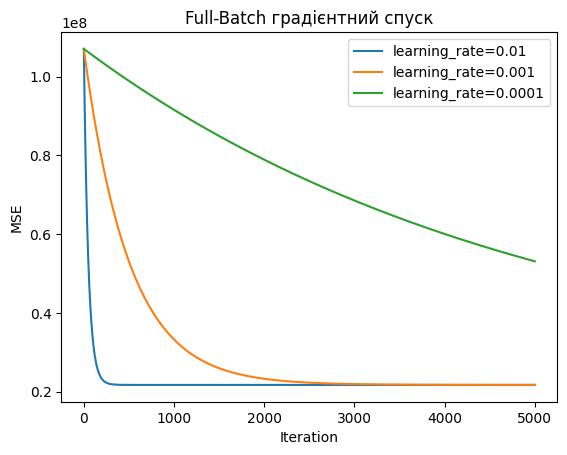

Best param:
Learning rate = 0.01
Weight = 3762.0069
Bias = 8434.27
RMSE = 4662.51


In [ ]:
learning_rate_list = [0.01, 0.001, 0.0001]

results, histories, models = test_learning_rate(X, y, learning_rate_list, epochs=5000)
draw_learning_rate(learning_rate_list, histories, results, models)

**Поведінка MSE**

`learning_rate = 0.01`
- Дуже швидка збіжність
- Найменший MSE за 5000 ітерацій
- Працює лише тому, що X нормалізований

`learning_rate = 0.001`
- Стабільна, гладка збіжність
- Дуже близький фінальний MSE
- Найбезпечніший варіант

`learning_rate = 0.0001`
- Стабільна
- Дуже повільна
- За 5000 ітерацій не встигає дійти до мінімуму

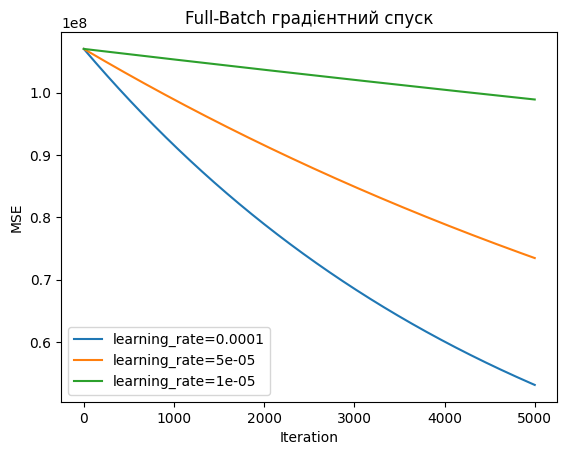

Best param:
Learning rate = 0.0001
Weight = 1480.2914
Bias = 3318.75
RMSE = 7287.91


In [ ]:
learning_rate_list = [1e-4, 5e-5, 1e-5]

results_min, histories_min, models_min = test_learning_rate(X, y, learning_rate_list, epochs=5000)
draw_learning_rate(learning_rate_list, histories_min, results_min, models_min)

**Поведінка MSE**

`learning_rate = 1e-4`
- MSE монотонно зменшується
- За 5000 ітерацій модель ще не доходить до мінімуму
- Дає найменший RMSE у цій групі

`learning_rate = 5e-5`
- Стабільна збіжність
- Помітно повільніша, ніж при `1e-4`
- За фіксовану кількість ітерацій залишається далі від мінімуму

`learning_rate = 1e-5`
- Дуже стабільна
- Надто повільна збіжність
- За 5000 ітерацій майже не навчається

In [ ]:
best_lr = min(results, key=lambda t: t[0])[1]
best_model = models[best_lr]

# Відновлюємо масштаб
age_mean = age.mean()
age_std = age.std()

charges_gd = (best_model.weight[0] * ((age_line - age_mean) / age_std) + best_model.bias)

## `sklearn.LinearRegression` для порівняння

In [ ]:
from sklearn.linear_model import LinearRegression

X_sklearn = non_smoker_df[['age']]

model = LinearRegression()
model.fit(X_sklearn, y)

b_sklearn = model.intercept_
w_sklearn = model.coef_[0]

y_pred_skl = model.predict(X_sklearn)
rmse_skl = rmse(y, y_pred_skl)

print('sklearn LinearRegression')
print('Sklearn coefficients:')
print(f'Intercept: {b_sklearn:.4f}')
print(f'Slope: {w_sklearn:.4f}')
print(f'RMSE: {rmse_skl:.2f}')

charges_sklearn = b_sklearn + w_sklearn * age_line

sklearn LinearRegression
Sklearn coefficients:
Intercept: -2091.4206
Slope: 267.2489
RMSE: 4662.51


## Графік

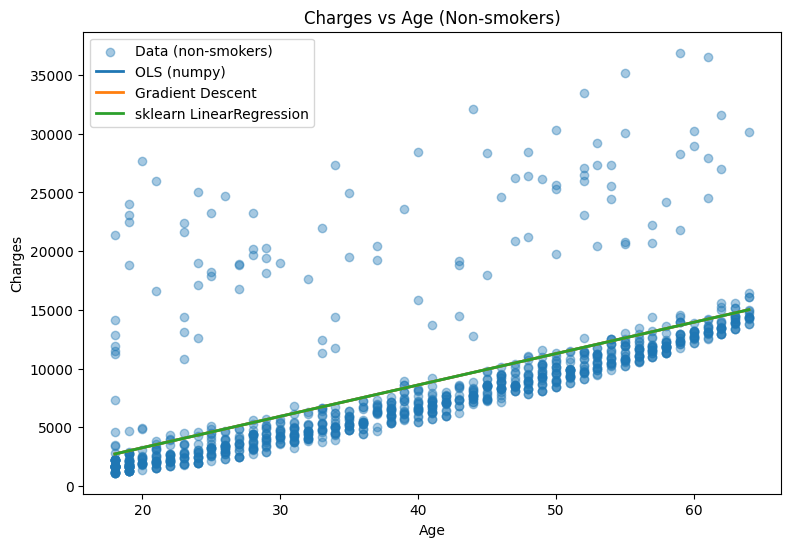

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(age, charges, alpha=0.4, label='Data (non-smokers)')
plt.plot(age_line, charges_ols, label='OLS (numpy)', linewidth=2)
plt.plot(age_line, charges_gd, label='Gradient Descent', linewidth=2)
plt.plot(age_line, charges_sklearn, label='sklearn LinearRegression', linewidth=2)

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Charges vs Age (Non-smokers)')
plt.legend()
plt.show()

Усі три лінії майже повністю накладаються:
- реалізація МНК (numpy) — коректна
- градієнтний спуск збігся до того ж мінімуму
- `sklearn` підтверджує результат

### Висновок
- Великі learning rate (0.01) забезпечують дуже швидку збіжність, але знаходяться на межі стабільності
- Середні значення (0.001) дають найкращий баланс між швидкістю та стабільністю
- Занадто малі learning rate (≤ 1e-4) потребують значно більшої кількості ітерацій

Рекомендований learning rate з практичної точки зору: `0.001`

# Task 2

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [ ]:
# Дані тільки для курців
smoker_df = medical_df[medical_df['smoker'] == 'yes']

X = smoker_df[['age']]
y = smoker_df['charges'].values

In [ ]:
model = LinearRegression()
model.fit(X, y)

b = model.intercept_
w = model.coef_[0]

y_pred = model.predict(X)

rmse_smoker = np.sqrt(np.mean((y - y_pred) ** 2))

print('Sklearn LinearRegression (smokers)')
print(f'Intercept (bias): {b:.2f}')
print(f'Slope (weight): {w:.2f}')
print(f'RMSE: {rmse_smoker:.2f}')

Sklearn LinearRegression (smokers)
Intercept (bias): 20294.13
Slope (weight): 305.24
RMSE: 10711.00


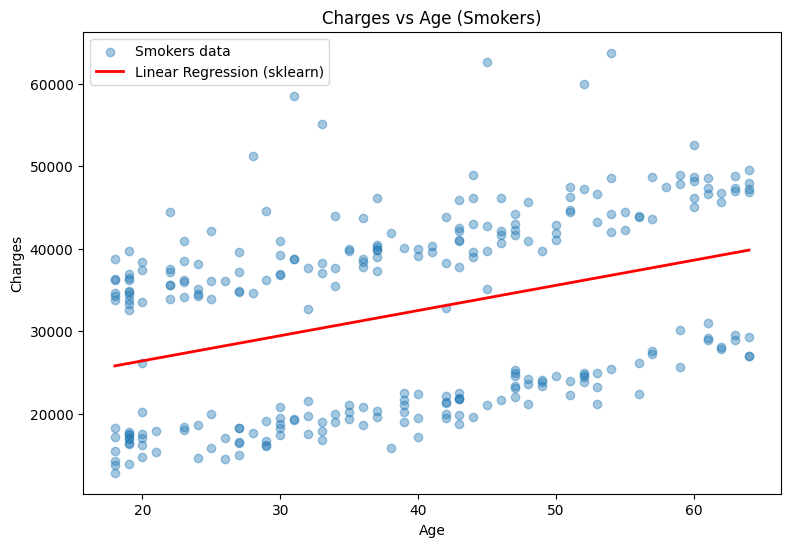

In [ ]:
age = smoker_df['age'].values
age_line = np.linspace(age.min(), age.max(), 100)

charges_line = b + w * age_line

plt.figure(figsize=(9, 6))

plt.scatter(age, y, alpha=0.4, label='Smokers data')
plt.plot(age_line, charges_line, color='red', linewidth=2,
         label='Linear Regression (sklearn)')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Charges vs Age (Smokers)')
plt.legend()
plt.show()


- RMSE є досить великим, що свідчить про значний розкид даних
- На графіку видно, що точки сильно розкидані навколо лінії
- Лінійна регресія ловить загальний напрям, але помилка прогнозу велика
> Чи використовували б ми таку модель в компанії?
ні, не в такому вигляді

Модель, що використовує лише вік для прогнозування медичних витрат курців, є занадто спрощеною, що можно побачити на графіку. Вона може давати лише грубу оцінку тренду, але не забезпечує достатньої точності для практичного використання в компанії
